# 6 Unsupervised Models

Using the model-ready player features, this notebook explores whether players form meaningful groups based on workload, physical attributes, schedule context, and injury history.

We apply **K-Means** and **Hierarchical Clustering** after standardizing the features. Cluster quality is evaluated using silhouette scores, inertia where applicable, cluster balance, and visual inspection through PCA projections. Injury-report outcomes are then compared across exploratory clusters, but the target itself is excluded from clustering.


## 6.1 Prerequisites and Loading Data

In [130]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import linkage, dendrogram

# === Configuration ===
PROCESSED_DIR = '../data/processed'
pd.set_option('display.max_columns', 50)

In [131]:
train_df = pd.read_csv(f'{PROCESSED_DIR}/train.csv')

print(f"Loaded: {train_df.shape[0]:,} rows, {train_df.shape[1]} cols")
print(f"Columns: {train_df.columns.tolist()}")
train_df.head()

Loaded: 1,620 rows, 16 cols
Columns: ['min', 'gp', 'dist_miles', 'usg_pct', 'ts_pct', 'age', 'player_height_inches', 'player_weight', 'injured_last_season', 'injury_report_count_last_season', 'b2b_games', 'age_x_minutes', 'weight_x_minutes', 'b2b_x_minutes', 'age_x_weight', 'target_next_season']


,min,gp,dist_miles,usg_pct,ts_pct,age,player_height_inches,player_weight,injured_last_season,injury_report_count_last_season,b2b_games,age_x_minutes,weight_x_minutes,b2b_x_minutes,age_x_weight,target_next_season
0,20.5,54,1.4,0.190,0.467,38.0,83.0,253.0,0.0,0.0,20,779.0,5186.5,410.0,9614.0,1
1,20.3,47,1.4,0.179,0.496,39.0,83.0,253.0,0.0,0.0,19,791.7,5135.9,385.7,9867.0,0
2,29.5,6,1.9,0.290,0.505,35.0,78.0,205.0,0.0,0.0,19,1032.5,6047.5,560.5,7175.0,2
3,34.5,35,2.2,0.337,0.477,36.0,78.0,212.0,1.0,1.0,16,1242.0,7314.0,552.0,7632.0,3
4,29.2,74,1.9,0.251,0.535,38.0,83.0,250.0,0.0,0.0,19,1109.6,7300.0,554.8,9500.0,0


## 6.2 Preprocessing

The target variable is excluded from the clustering features. We also compare feature sets with and without the engineered multiplication/interaction terms because those terms can affect distance-based clustering.


In [132]:
# Drop target for clustering (keep all 15 features)
X_train = train_df.drop(columns=['target_next_season'])

# Scale once
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_train)

## 6.2 K-Means + Visualizations

In [133]:
# Fit PCA once for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

In [134]:
# How much variance do these 2 components capture?
var1, var2 = pca.explained_variance_ratio_
print(f"PCA Component 1: {var1:.1%} variance explained")
print(f"PCA Component 2: {var2:.1%} variance explained")
print(f"Total (2 components): {var1 + var2:.1%}")

PCA Component 1: 37.8% variance explained
PCA Component 2: 17.3% variance explained
Total (2 components): 55.1%


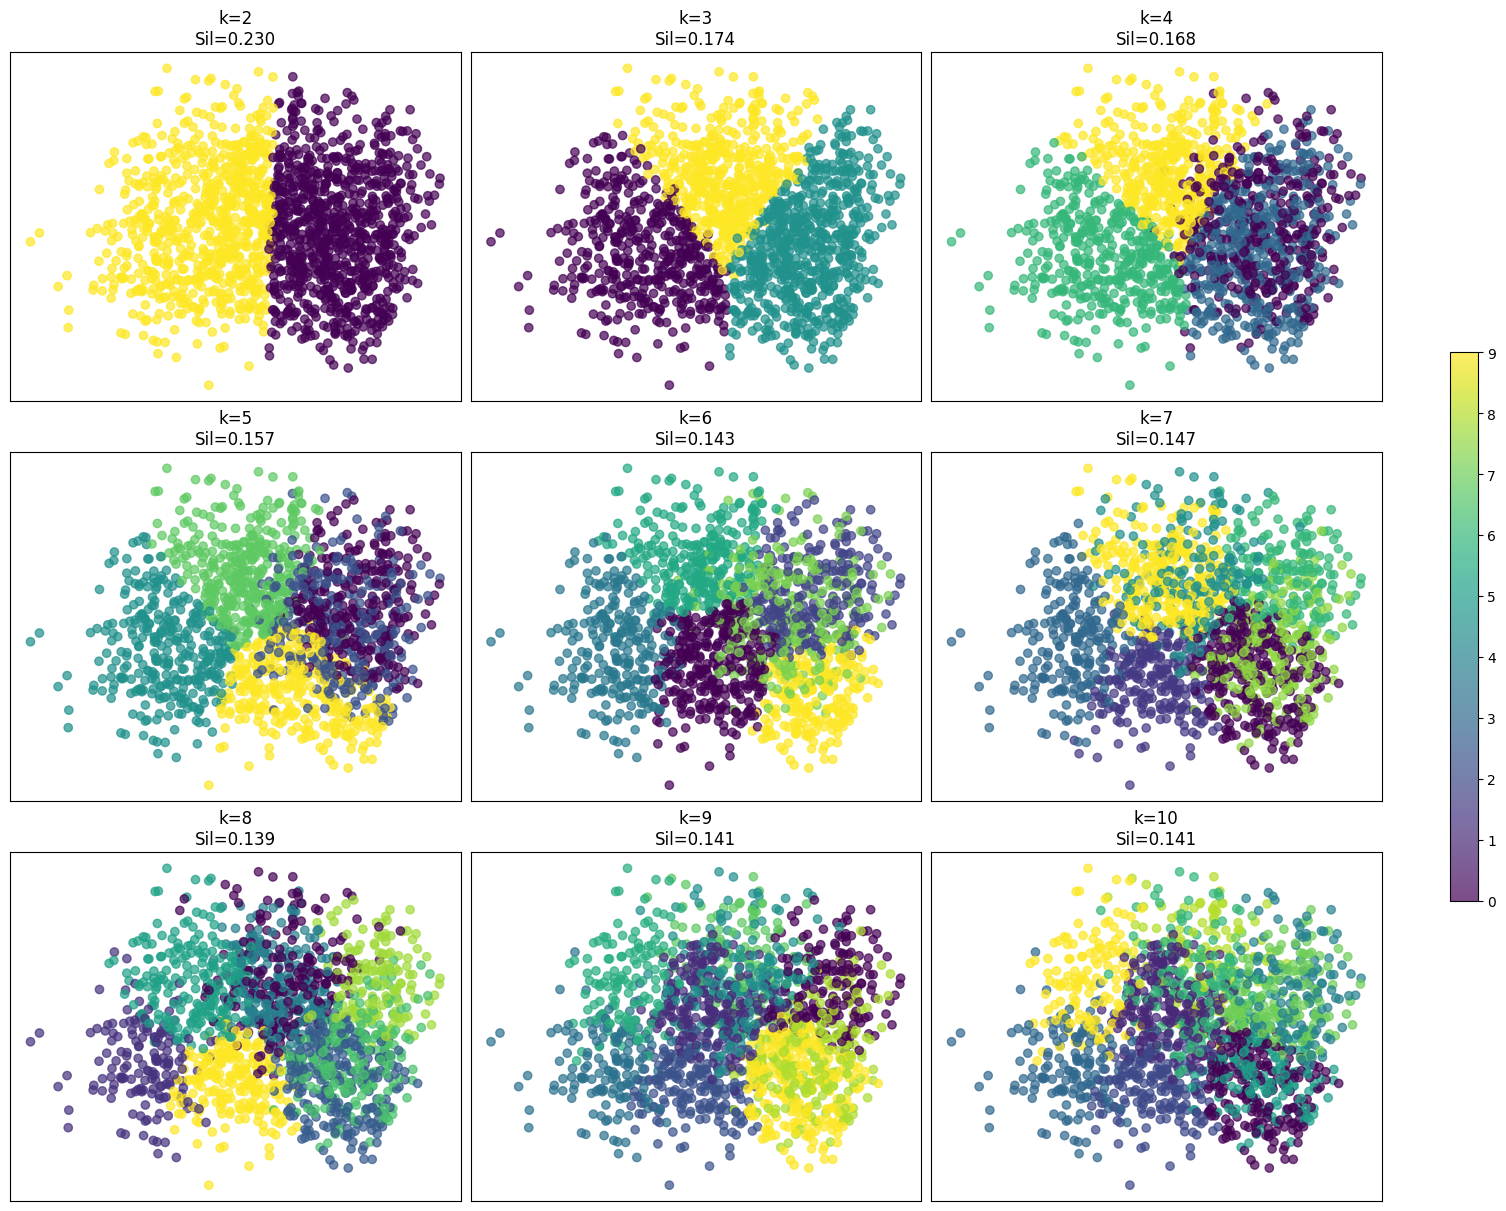

In [135]:
results = []

k_values = range(2, 11)
n_plots = len(k_values)

# Create grid (3x3 for 9 plots)
fig, axes = plt.subplots(3, 3, figsize=(15, 12), constrained_layout=True)
axes = axes.flatten()

for idx, k in enumerate(k_values):
    
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = kmeans.fit_predict(X_scaled)
    
    sil_score = silhouette_score(X_scaled, labels)
    
    results.append({
        "k": k,
        "silhouette_score": sil_score,
        "inertia": kmeans.inertia_
    })
    
    # Plot on subplot
    scatter = axes[idx].scatter(
        X_pca[:, 0],
        X_pca[:, 1],
        c=labels,
        cmap="viridis",
        alpha=0.7
    )
    
    axes[idx].set_title(f"k={k}\nSil={sil_score:.3f}")
    axes[idx].set_xticks([])
    axes[idx].set_yticks([])

fig.colorbar(scatter, ax=axes, orientation='vertical', fraction=0.02)
plt.show()

Both PCA visualizations and silhouette metrics suggest limited intrinsic cluster structure in the data. The PCA projections show substantial overlap among cluster assignments, with no clearly defined boundaries between groups. Additionally, silhouette scores peak at a modest 0.23 for 
𝑘 = 2 and decrease for larger values of 𝑘, indicating weak separation and cohesion. These findings imply that injury risk and workload characteristics may lie on a continuous spectrum rather than forming sharply defined categorical groupings.

### Elbow Plot - Plotting the Inertia vs. k

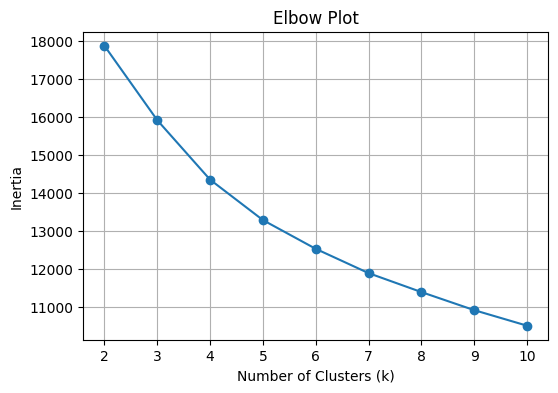

In [136]:
results_df = pd.DataFrame(results)

plt.figure(figsize=(6,4))
plt.plot(results_df["k"], results_df["inertia"], marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Plot")
plt.xticks(results_df["k"])
plt.grid(True)
plt.show()

### Plotting Sihouette Score vs. k

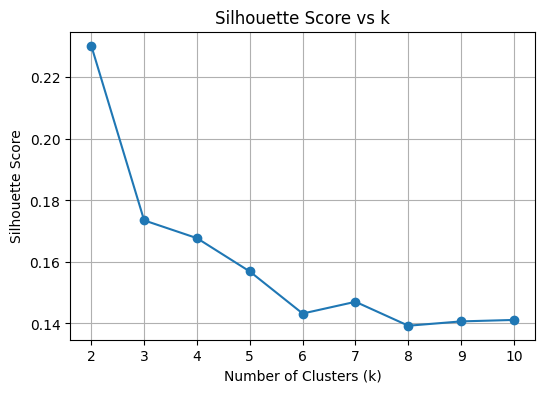

In [137]:
plt.figure(figsize=(6,4))
plt.plot(results_df["k"], results_df["silhouette_score"], marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score vs k")
plt.xticks(results_df["k"])
plt.grid(True)
plt.show()

The elbow plot and silhouette score plot further reinforce the conclusion that the dataset exhibits weak cluster structure. In the elbow plot, the inertia decreases gradually without a clear inflection point, indicating the absence of a well-defined “elbow” and no obvious optimal value of k. Similarly, the silhouette scores peak at k = 2, but the maximum value of 0.23 is relatively low. This suggests that even at the best-performing cluster count, the separation between clusters is weak and there is substantial overlap among data points.

## 6.3 Hierarchical Clustering + Visualizations

In [138]:
# Drop target for clustering (keep all 15 features)
X_train = train_df.drop(columns=['target_next_season', 'age_x_minutes', 'weight_x_minutes', 'b2b_x_minutes', 'age_x_weight'])

# Scale once
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_train)

Compute Linkage Matrix

In [139]:
Z = linkage(X_scaled, method="average")

Plot Dendrogram from Linkage Matrix

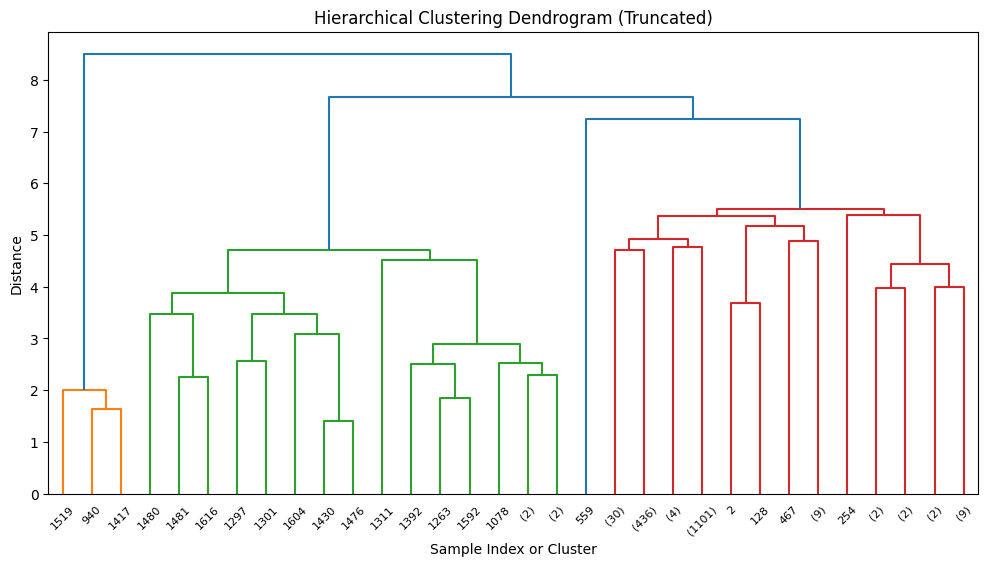

In [140]:
plt.figure(figsize=(12,6))
dendrogram(Z, truncate_mode="level", p=6)
plt.title("Hierarchical Clustering Dendrogram (Truncated)")
plt.xlabel("Sample Index or Cluster")
plt.ylabel("Distance")
plt.show()

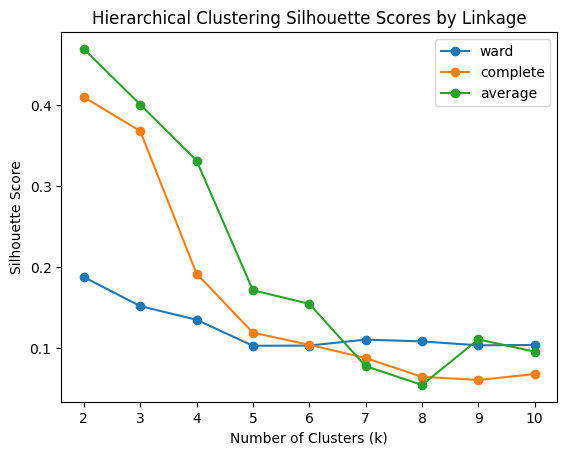

     linkage   k  silhouette                                                                 cluster_counts
0       ward   2    0.187913                                                              {0: 1121, 1: 499}
1       ward   3    0.152065                                                       {0: 553, 2: 568, 1: 499}
2       ward   4    0.135123                                               {2: 342, 0: 568, 1: 499, 3: 211}
3       ward   5    0.103002                                       {2: 342, 3: 236, 4: 332, 0: 499, 1: 211}
4       ward   6    0.103244                               {2: 342, 3: 236, 4: 332, 5: 194, 0: 305, 1: 211}
5       ward   7    0.110611                        {0: 342, 3: 236, 4: 332, 5: 194, 2: 240, 6: 65, 1: 211}
6       ward   8    0.108381                 {7: 86, 3: 236, 4: 332, 5: 194, 2: 240, 6: 65, 1: 256, 0: 211}
7       ward   9    0.103571          {7: 86, 3: 236, 4: 332, 2: 194, 0: 240, 6: 65, 1: 256, 8: 136, 5: 75}
8       ward  10    0.103932

In [141]:
linkages = ["ward", "complete", "average"]
k_values = range(2, 11)

results = []

for linkage in linkages:
    for k in k_values:
        model = AgglomerativeClustering(
            n_clusters=k,
            linkage=linkage
        )
        labels = model.fit_predict(X_scaled)
        score = silhouette_score(X_scaled, labels)
        
        # Count number of samples in each cluster
        cluster_counts = Counter(labels)
        
        results.append({
            "linkage": linkage,
            "k": k,
            "silhouette": score,
            "cluster_counts": dict(cluster_counts)
        })

results_df = pd.DataFrame(results)

plt.figure()

for linkage in linkages:
    subset = results_df[results_df["linkage"] == linkage]
    
    plt.plot(
        subset["k"], 
        subset["silhouette"], 
        marker="o",
        label=linkage
    )

plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Hierarchical Clustering Silhouette Scores by Linkage")
plt.xticks(range(2, 11))
plt.legend()
plt.show()

# Set options to display all rows, columns, and full column width
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
# Optional: Adjust the display width to prevent wrapping issues in the console
pd.set_option('display.width', 1000)

results_df = pd.DataFrame(results)
print(results_df)

Hierarchical clustering produces higher silhouette scores than K-Means for some configurations. At `k=2`, average linkage reaches approximately 0.38–0.47 depending on the tested feature set. However, the highest-scoring average-linkage solution is extremely imbalanced (1,617 observations in one cluster and 3 in the other), limiting its usefulness as a broad player segmentation.


Taken together, K-Means and Hierarchical Clustering do not provide strong evidence of clean, stable injury-risk archetypes in the selected feature space. K-Means produces more balanced exploratory groups but weak silhouette separation, while higher-scoring hierarchical configurations can be dominated by very small outlier clusters. The player characteristics therefore appear better described as overlapping or continuous rather than as sharply separated categories.


In [142]:
# === Cluster Profiling: What do the 2 clusters look like? ===
kmeans_best = KMeans(n_clusters=2, random_state=42, n_init=20)
train_df['cluster'] = kmeans_best.fit_predict(X_scaled)

# Mean feature values per cluster
feature_cols = [c for c in train_df.columns if c not in ['target_next_season', 'cluster']]
profile = train_df.groupby('cluster')[feature_cols].mean().T
profile.columns = ['Cluster 0', 'Cluster 1']
profile['Difference'] = profile['Cluster 1'] - profile['Cluster 0']

print(f"Cluster sizes: {train_df['cluster'].value_counts().to_dict()}")
print(f"\n--- Cluster Profiles (Mean Feature Values) ---")
profile.round(2)

Cluster sizes: {0: 911, 1: 709}

--- Cluster Profiles (Mean Feature Values) ---


,Cluster 0,Cluster 1,Difference
min,27.99,13.82,-14.17
gp,69.61,45.11,-24.50
dist_miles,1.95,0.99,-0.96
usg_pct,0.20,0.16,-0.04
ts_pct,0.55,0.51,-0.04
age,27.38,25.69,-1.69
player_height_inches,78.79,79.37,0.58
player_weight,220.11,221.07,0.96
injured_last_season,0.45,0.12,-0.33
injury_report_count_last_season,1.02,0.19,-0.82


For the more balanced `k=2` K-Means solution, height, weight, and back-to-back counts are similar across clusters, while workload and injury-history measures differ more visibly. We next compare injury-report outcomes across these exploratory groups.


In [143]:
# === Do clusters differ in actual injury outcomes? ===
injury_by_cluster = train_df.groupby('cluster')['target_next_season'].agg(['mean', 'median', 'std', 'count'])
injury_by_cluster.columns = ['Mean Injuries', 'Median Injuries', 'Std', 'Count']
print("--- Injury Outcomes by Cluster ---")
print(injury_by_cluster.round(3))

pct_injured = train_df.groupby('cluster')['target_next_season'].apply(lambda x: (x > 0).mean())
print(f"\n% of players with at least 1 injury report:")
print(f"  Cluster 0 (high-usage): {pct_injured[0]:.1%}")
print(f"  Cluster 1 (low-usage):  {pct_injured[1]:.1%}")

--- Injury Outcomes by Cluster ---
         Mean Injuries  Median Injuries    Std  Count
cluster                                              
0                1.762              1.0  1.658    911
1                0.965              1.0  1.283    709

% of players with at least 1 injury report:
  Cluster 0 (high-usage): 72.2%
  Cluster 1 (low-usage):  51.1%


### Sensitivity Analysis

In [144]:
# === Sensitivity Analysis: Linkage Method Comparison ===
linkage_methods = ['ward', 'complete', 'average']
sensitivity_results = []

for method in linkage_methods:
    for k in [2, 3, 4, 5, 6, 7, 8, 9, 10]:
        model = AgglomerativeClustering(n_clusters=k, linkage=method)
        labels = model.fit_predict(X_scaled)
        sil = silhouette_score(X_scaled, labels)
        sensitivity_results.append({'Linkage': method, 'k': k, 'Silhouette': round(sil, 3)})

sensitivity_df = pd.DataFrame(sensitivity_results).pivot(index='Linkage', columns='k', values='Silhouette')
print("--- Hierarchical Clustering: Sensitivity to Linkage Method WITHOUT Mulitplied Features ---")
print(sensitivity_df)

--- Hierarchical Clustering: Sensitivity to Linkage Method WITHOUT Mulitplied Features ---
k            2      3      4      5      6      7      8      9      10
Linkage                                                                
average   0.470  0.401  0.332  0.172  0.155  0.078  0.055  0.111  0.096
complete  0.410  0.368  0.192  0.119  0.104  0.088  0.065  0.061  0.068
ward      0.188  0.152  0.135  0.103  0.103  0.111  0.108  0.104  0.104


In [145]:
# Drop target for clustering (keep all 15 features)
X_train2 = train_df.drop(columns=['target_next_season'])

# Scale once
scaler2 = StandardScaler()
X_scaled2 = scaler2.fit_transform(X_train2)

sensitivity_results2 = []

for method in linkage_methods:
    for k in [2, 3, 4, 5, 6, 7, 8, 9, 10]:
        model = AgglomerativeClustering(n_clusters=k, linkage=method)
        labels = model.fit_predict(X_scaled2)
        sil = silhouette_score(X_scaled2, labels)
        sensitivity_results2.append({'Linkage': method, 'k': k, 'Silhouette': round(sil, 3)})

sensitivity_df = pd.DataFrame(sensitivity_results2).pivot(index='Linkage', columns='k', values='Silhouette')
print("--- Hierarchical Clustering: Sensitivity to Linkage Method WITH Multiplied Features ---")
print(sensitivity_df)

--- Hierarchical Clustering: Sensitivity to Linkage Method WITH Multiplied Features ---
k            2      3      4      5      6      7      8      9      10
Linkage                                                                
average   0.372  0.317  0.210  0.135  0.124  0.195  0.176  0.132  0.119
complete  0.327  0.184  0.180  0.086  0.083  0.078  0.074  0.081  0.069
ward      0.268  0.213  0.149  0.116  0.122  0.116  0.127  0.125  0.114


## 6.4 Identifying Potential Outliers from Clustering Results

Although the clustering results do not show strong natural segmentation, distance-based methods can still flag observations with unusual feature profiles. The following section examines these potential outliers descriptively rather than treating them as a distinct injury-risk class.


In [146]:
# === Outlier Detection: Identify unusual player profiles ===
distances = np.linalg.norm(
    X_scaled - kmeans_best.cluster_centers_[train_df['cluster'].values], 
    axis=1
)

train_df['distance_to_centroid'] = distances
threshold = np.percentile(distances, 97)
outliers = train_df[train_df['distance_to_centroid'] > threshold].copy()

# Label archetypes
outliers['archetype'] = outliers['cluster'].map({0: 'High-usage', 1: 'Low-usage'})

print(f"Outlier threshold (97th percentile): {threshold:.2f}")
print(f"Number of outliers: {len(outliers)}\n")

outlier_display = outliers[['archetype', 'min', 'gp', 'age', 'player_weight',
                            'injury_report_count_last_season', 'target_next_season', 
                            'distance_to_centroid']].sort_values('distance_to_centroid', ascending=False)
print("--- Top 10 Outlier Profiles ---")
outlier_display.head(10)

Outlier threshold (97th percentile): 4.60
Number of outliers: 49

--- Top 10 Outlier Profiles ---


,archetype,min,gp,age,player_weight,injury_report_count_last_season,target_next_season,distance_to_centroid
1480,Low-usage,3.1,3,23.0,185.0,2.0,0,8.561653
1616,Low-usage,0.8,1,24.0,215.0,0.0,0,8.489133
1481,Low-usage,2.0,3,22.0,230.0,0.0,1,8.431881
1301,Low-usage,5.5,1,26.0,186.0,0.0,0,8.242534
1297,Low-usage,3.9,2,24.0,185.0,0.0,2,7.878132
1417,Low-usage,0.7,3,23.0,218.0,0.0,1,7.526412
940,Low-usage,1.4,1,26.0,209.0,0.0,0,7.488423
1519,Low-usage,6.1,1,24.0,250.0,0.0,0,7.421376
1311,Low-usage,3.4,2,24.0,204.0,0.0,0,6.884625
559,High-usage,17.0,75,29.0,230.0,8.0,2,6.510949


Many of the flagged outliers have very limited games played and low usage. The available data do not establish why those player-seasons have atypical profiles, so possible explanations such as injury timing, roster transactions, or short-term contracts should be treated as hypotheses rather than conclusions.


## 6.5 Summary

No single clustering configuration provides both strong separation and broadly useful cluster balance.

- **K-Means (`k=2`)** produces a relatively balanced two-group segmentation but a low silhouette score of approximately **0.23**, indicating weak separation.
- **Hierarchical clustering with average linkage** reaches a higher silhouette score in sensitivity analysis, but the strongest-scoring `k=2` solution is extremely imbalanced, limiting its usefulness as a general player-archetype model.
- The balanced K-Means groups differ primarily in workload and injury-history measures; the higher-usage group also has a higher observed injury-report prevalence in this dataset.
- PCA projections show substantial overlap, supporting the interpretation that player profiles vary along a continuum rather than forming clean injury-risk categories.
- Outlier analysis identifies atypical low-games-played profiles, but the data do not establish the reasons for those observations.

**Connection to supervised learning:** both analyses suggest that the available features contain some structure related to workload and injury history, but the overall signal is limited and does not support sharply separated injury-risk categories.
